In [2]:
#### Necessary libraries ####

import numpy as np  # Numpy is the fundamental package for scientific computing in Python.
import pandas as pd
from Functions import *
import pylab
from combine_data import read_data, read_precip_era5, read_tracked_precip
from paths import basedir, figure_path
import cmocean

#Scientific libraries
from sklearn.decomposition import PCA   
from sklearn.cluster import KMeans
import seaborn as sns
from eofs.xarray import Eof #Import eofs package

#plotting
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches

# The statement below enforces the plots to be put into this notebook, instead of in their own windows.
%matplotlib inline

In [3]:
# Some settings parameters for the clustering analysis and plotting
n_clusters = 2  # Number of clusters for KMeans
n_init = 100  # Number of initializations for KMeans    
n_pcs = 10  # Number of principal components to use for clustering
random_state = None  # Random state for reproducibility

normalize = False  # Whether to normalize the data before clustering
plot_pca_cases = False  # Whether to plot the PCA case plots
plot_clusters = True  # Whether to plot the clustering results  
print_labels = False  # Whether to print the cluster labels for each model run
plot_other_members = False  # Whether to plot the other members of each cluster 

fontsize = 12

In [4]:
# Settings 
cases = ["Pakistan","Australia","Scotland"]

# TODO: fix WAM2layers units (?)
list_reordered = [
    "WAM2layers",
    "2LDRM",
    #'UTrack Ens1',
    "UTrack Ens2",
    #'UTrack Ens3',
    #'UTrack Ens4',
    #'UTrack Ens5',
    "BTrIMS",
    "TRACMASS",
    #'FLEXPART-HAMSTER Ens1',
    #'FLEXPART-HAMSTER Ens2',
    #'FLEXPART-HAMSTER Ens3',
    #'FLEXPART-HAMSTER Ens4',
    "FLEXPART-SSW08 (HAMSTER) Ens5",
    "FLEXPART-SSW08 (WaterSip)",
    "FLEXPART-SSW08 (UniVie)",
    "LAGRANTO-SSW08",
    "FLEXPART-SSW08 (IBCAS)",
    "FLEXPART-SSW08 (HKUST) Ens2",
    "FLEXPART-SSW08 (LATTIN)",
    #'WRF-WVT',
    "FLEXPART-SJ04 (LATTIN)",
]

# Assign a color for each model
colors = {
    "WRF-WVT": "limegreen",
    "WAM2layers": "yellow",
    "2LDRM": "orange",
    "UTrack": "red",
    "BTrIMS": "firebrick",
    "TRACMASS": "teal",
    "FLEXPART-SSW08 (HAMSTER)": "cyan",
    "FLEXPART-SSW08 (WaterSip)": "lightblue",
    "FLEXPART-SSW08 (UniVie)": "deepskyblue",
    "LAGRANTO-SSW08": "cornflowerblue",
    "FLEXPART-SSW08 (IBCAS)": "blue",
    "FLEXPART-SSW08 (HKUST)": "navy",
    "FLEXPART-SSW08 (LATTIN)": "mediumslateblue",
    "FLEXPART-SJ04 (LATTIN)": "purple",
}

In [5]:
# For a custom legend
# Adapted from https://matplotlib.org/stable/users/explain/axes/legend_guide.html#implementing-a-custom-legend-handler

from matplotlib.legend_handler import HandlerPatch
class HandlerEllipse(HandlerPatch):
    def create_artists(
        self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans
    ):
        center = 0.5 * width - 0.5 * xdescent, 0.5 * height - 0.5 * ydescent
        p = mpatches.Circle(xy=center, radius=5)
        self.update_prop(p, orig_handle, legend)
        p.set_transform(trans)
        return [p]

# Data loading & Calculation of clusters

In [6]:
#Results storage
kmeans_results = {}
pca_results = {}

# Loop over cases
for case in cases:
    print(f"Processing case: {case}")

    ########################################################
    ## import model runs                                  ##
    ########################################################
    ds_sources = read_data(basedir, case)
    if(case=="Australia"):
        #regrid longitudes to 0-360
        ds_sources = ds_sources.assign_coords(lon=(((ds_sources.lon + 360) % 360)))
        #reorder longitudes
        ds_sources = ds_sources.sortby('lon')
    
    ########################################################
    ## preprocess model runs                              ##
    ########################################################

    #### model runs for plotting ####
    all_maps = {kk: ds_sources[kk] for kk in list_reordered}
    all_maps_other = {kk: ds_sources[kk] for kk in ds_sources.data_vars if kk not in list_reordered}
    all_maps = xr.Dataset(all_maps)
    all_maps_other = xr.Dataset(all_maps_other)
    
    maps_features = {
        # case: [central_longitude, lonmin, lonmax, latmin, latmax]
        "Scotland": [0, -85, 40, 10, 80],
        "Pakistan": [0, 0, 140, -40, 50],
        "Australia": [180, 120, 240, -60, 10],
    }

    #Select area of interest without nans
    if(case=="Pakistan"):
        #[20.0, 120.0, -30.0, 40.0]
        all_maps = all_maps.sel(lat=slice(-40, 50), lon=slice(0, 140))
        all_maps_other = all_maps_other.sel(lat=slice(-40, 50), lon=slice(0, 140))
    elif(case=="Australia"):
        #([-160.0, 180.0, -80.0, 20.0])
        all_maps = all_maps.sel(lat=slice(-60, 10), lon=slice(120, 240))
        all_maps_other = all_maps_other.sel(lat=slice(-60, 10), lon=slice(120, 240))
    elif(case=="Scotland"):
        #[-100.0, 50.0, 5.0, 60.0]
        all_maps = all_maps.sel(lat=slice(10, 80), lon=slice(-85, 40))
        all_maps_other = all_maps_other.sel(lat=slice(10, 80), lon=slice(-85, 40))

    #Set nans to zero
    all_maps = all_maps.fillna(0)
    all_maps_other = all_maps_other.fillna(0)

    #Normalize data
    #if(normalize):
    #    all_maps_nonnormalized = all_maps.copy()
    #    for model in all_maps.data_vars:
    #        data = all_maps[model].values
    #        data_min = np.min(data)
    #        data_max = np.max(data)
    #        all_maps[model].values = (data - data_min) / (data_max - data_min)

    #########################################################
    ## PCA analysis                                        ##
    #########################################################
    #Use normalized data for PCA using standard scaler
    from sklearn.preprocessing import StandardScaler

    if(normalize):
        scaler = StandardScaler(with_mean=False)
        all_maps_reshaped = all_maps.to_array().transpose("variable", "lat",
            "lon").values.reshape(13, -1)
        all_maps_reshaped = scaler.fit_transform(all_maps_reshaped)
    else:
        all_maps_reshaped = all_maps.to_array().transpose("variable", "lat",
            "lon").values.reshape(13, -1)
        all_maps_other_reshaped = all_maps_other.to_array().transpose("variable", "lat",
            "lon").values.reshape(len(all_maps_other.data_vars), -1)

    #Perform PCA
    pca = PCA(n_components=n_pcs)      
    pca_result = pca.fit_transform(all_maps_reshaped)   
    explained_variance = pca.explained_variance_ratio_
    print(f"Explained variance by the first {n_pcs} principal components: {explained_variance}")

    #Store PCA results
    pca_results[case] = {
        'pca_object': pca,
        'pca_result': pca_result,
        'explained_variance': explained_variance    
    }

    #Project other model runs onto the PCA space
    other_models_pca_projection = {}
    for model in all_maps_other.data_vars:
        model_data = all_maps_other[model].values.flatten()
        if(normalize):
            model_data = scaler.transform(model_data.reshape(1, -1))
        projection = pca.transform(model_data.reshape(1, -1))
        other_models_pca_projection[model] = projection

    #Make a plot of the first two principal components
    #Try to reduce text overlap with adjustText package?    
    if(plot_pca_cases):
        plt.figure(figsize=(8,6))
        for i, model in enumerate(all_maps.data_vars):
            plt.scatter(pca_result[i,0], pca_result[i,1], s=100, color=colors[model])
        #for i, model in enumerate(all_maps.data_vars):
            plt.text(pca_result[i,0]+0.01, pca_result[i,1]+0.01, model, color='gray', fontsize=8)
            
        plt.title(f'PCA of model runs for {case} case')
        plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2f})')
        plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2f})')
        plt.grid()
        plt.show()  
        plt.savefig(figure_path+f'PrincipleComponents_{case}.png', dpi=300)
  
    ########################################################
    ## Clustering analysis                               ##
    ########################################################
    #Do a clustering analysis to group similar model runs together
    kmeans  = KMeans(n_clusters=n_clusters, n_init=n_init,random_state=random_state).fit(
        all_maps.to_array().transpose("variable", "lat", "lon").values.reshape(
            13, -1
        )
    )
    kmeans_results[case] = kmeans

    labels = kmeans.labels_
    if(print_labels):
        print("Cluster labels for each model run:")
        for i, model in enumerate(all_maps.data_vars):
            print(f"{model}: Cluster {labels[i]}") 

    # Calculate cluster centers
    cluster_centers = kmeans.cluster_centers_.reshape(n_clusters, all_maps.lat.size, all_maps.lon.size)
    kmeans_results[case+'_centers'] = cluster_centers
    
    # Also save longitude and latitude grids for plotting
    kmeans_results[case+'_lat'] = all_maps.lat
    kmeans_results[case+'_lon'] = all_maps.lon

    # Calculate distances to cluster centers
    distances = kmeans.transform(
        all_maps.to_array().transpose("variable", "lat", "lon").values.reshape(
            13, -1
        )
    )
    kmeans_results[case+'_distances'] = distances
    

Processing case: Pakistan
Loading WRF-WVT data for Pakistan
Loading wam2layers data for Pakistan
Loading 2ldrm data for Pakistan
Loading utrack data for Pakistan
Loading btrims data for Pakistan
Loading tracmass data for Pakistan
Loading ughent data for Pakistan
Loading UIB data for Pakistan
Loading UniVie data for Pakistan
Loading CHc data for Pakistan
Loading xu data for Pakistan
Loading tatfancheng data for Pakistan
Loading uvigo data for Pakistan
Explained variance by the first 10 principal components: [0.40135302 0.37426282 0.13654668 0.03104871 0.01787942 0.01005277
 0.00875066 0.00681586 0.00508885 0.00378562]


c:\Users\chris\OneDrive\Documenten\Data\Moisture_tracking_intercomparison\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Processing case: Australia
Loading WRF-WVT data for Australia
Loading wam2layers data for Australia
Loading 2ldrm data for Australia
Loading utrack data for Australia
Loading btrims data for Australia
Loading tracmass data for Australia
Loading ughent data for Australia
Loading UIB data for Australia
Loading UniVie data for Australia
Loading CHc data for Australia
Loading xu data for Australia
Loading tatfancheng data for Australia
Loading uvigo data for Australia
Explained variance by the first 10 principal components: [0.39272632 0.23200635 0.13240665 0.08212999 0.0557678  0.02942956
 0.02529917 0.01775045 0.01189224 0.00958177]


c:\Users\chris\OneDrive\Documenten\Data\Moisture_tracking_intercomparison\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Processing case: Scotland
Loading WRF-WVT data for Scotland
Loading wam2layers data for Scotland
Loading 2ldrm data for Scotland
Loading utrack data for Scotland
Loading btrims data for Scotland
Loading tracmass data for Scotland
Loading ughent data for Scotland
Loading UIB data for Scotland
Loading UniVie data for Scotland
Loading CHc data for Scotland
Loading xu data for Scotland
Loading tatfancheng data for Scotland
Loading uvigo data for Scotland
Explained variance by the first 10 principal components: [0.69355633 0.14457407 0.07494257 0.02664278 0.0223218  0.01096033
 0.00718559 0.00608224 0.00526663 0.00405504]


c:\Users\chris\OneDrive\Documenten\Data\Moisture_tracking_intercomparison\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# PLOTS

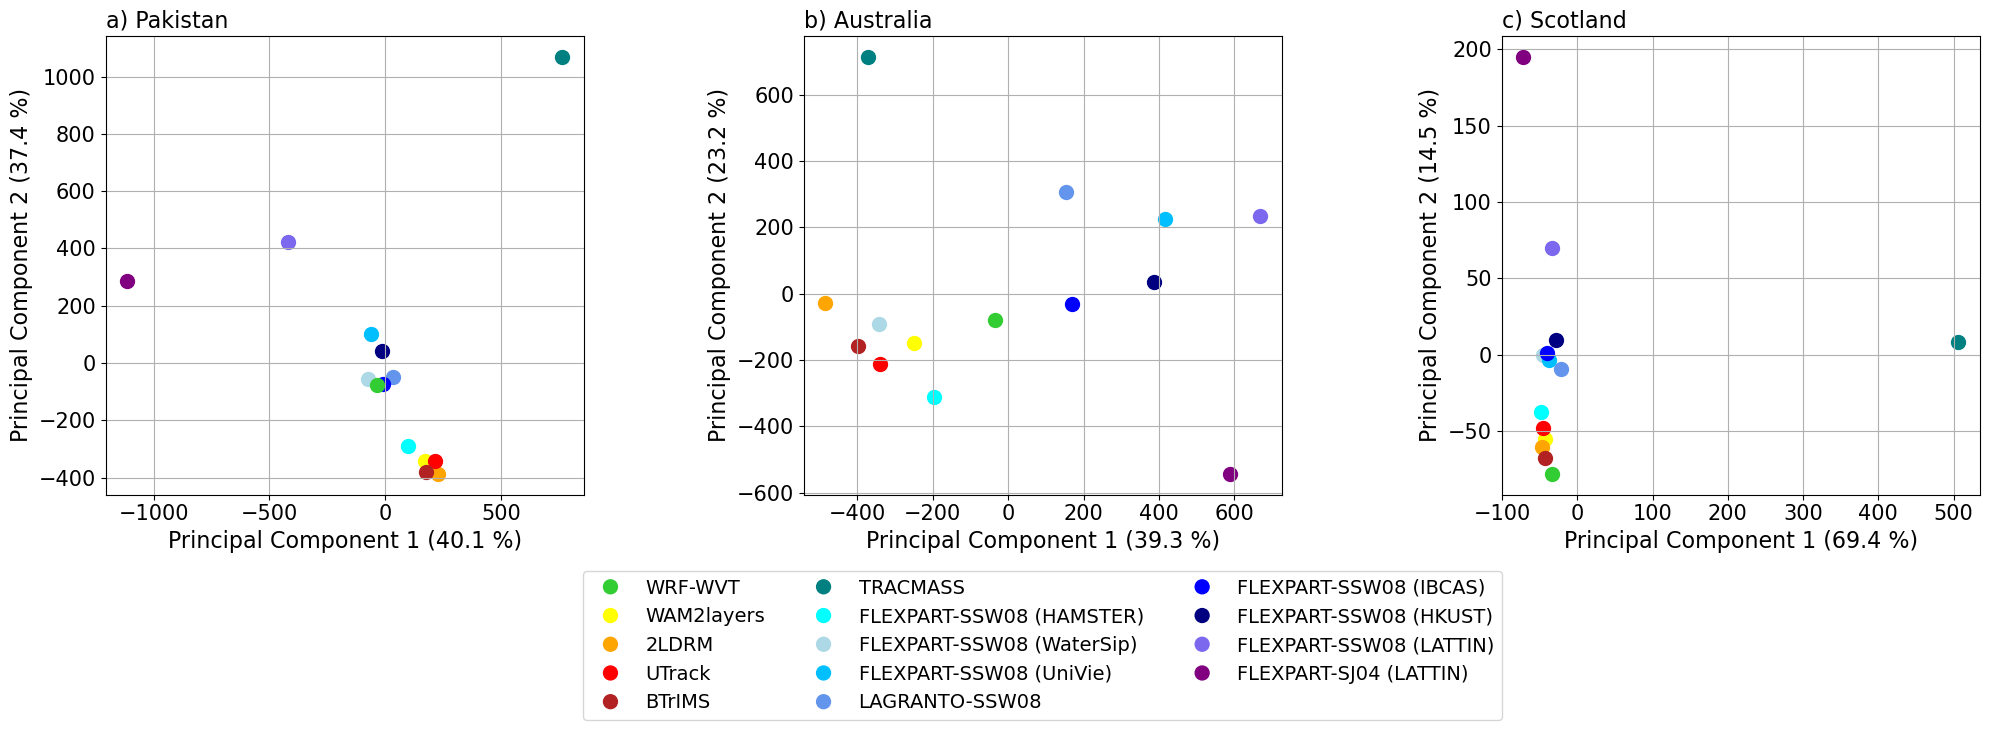

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 7.5), height_ratios=[12, 2])
plt.subplots_adjust(wspace=0.02, hspace=0.25)

subplot_labels = ['a)', 'b)', 'c)']
subplot_labels = [label + ' ' + case for label, case in zip(subplot_labels, cases)]

models = list(all_maps.data_vars) + list(all_maps_other.data_vars)
names = [
    model[: model.find("Ens")].rstrip(" ") if "Ens" in model else model
    for model in models
]

#Start by plotting legend in top row
ax = axs[1, 1]
fontsize = 16
fontsize_legend = 14

# Add legend
handles = [
    mpatches.Circle((0.5, 0.5), 1, color=color, label=label)
    for (label, color) in colors.items()
]
ax.legend(
    handles=handles,
    handler_map={mpatches.Circle: HandlerEllipse()},
    loc="lower center",
    ncols=3,
    prop={"size": fontsize_legend},
)

for i in range(3):
    axs[1,i].axis('off')

#Then plot the PCA subplots
for i, case in enumerate(cases):
    pca_result = pca_results[case]['pca_result']
    explained_variance = pca_results[case]['explained_variance']

    ax = axs[0,i]
    
    for j, model in enumerate(models):
        if(model in all_maps.data_vars):
            ax.scatter(pca_result[j,0], pca_result[j,1], s=100, color=colors[names[j]], label=model if i==0 else "")
            #ax.text(pca_result[j,0]+0.01, pca_result[j,1]+0.01, model, color='gray', fontsize=8)
        elif(model in all_maps_other.data_vars):
            projection = other_models_pca_projection[model]
            if(model == "WRF-WVT"):
                 ax.scatter(projection[0,0], projection[0,1], s=100, color=colors[names[j]], label=model if i==0 else "")
            else:
                 if(plot_other_members):
                    #ax.scatter(projection[0,0], projection[0,1], s=80, color=colors[names[j]], label=model if i==0 else "")
                    ax.scatter(projection[0,0], projection[0,1], s=80, linewidths=1, c="none", ec=colors[names[j]], label=model if i==0 else "")
    
    ax.set_title(f'{subplot_labels[i]}', fontsize=fontsize, loc='left')
    ax.set_xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f} %)',fontsize=fontsize)
    ax.set_ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f} %)',fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)
    ax.grid()

plt.tight_layout()
if(normalize):
    plt.savefig(figure_path+'PrincipleComponents_AllCases_Subplots_normalized.png', dpi=300)
else:
    plt.savefig(figure_path+'PrincipleComponents_AllCases_Subplots.png', dpi=300)
plt.show()

In [10]:
# Spatial EOF patterns
import cartopy.crs as ccrs
prj = ccrs.PlateCarree()

maps_features = {
    # case: [central_longitude, lonmin, lonmax, latmin, latmax]
    "Scotland": [0, -85, 40, 10, 80],
    "Pakistan": [0, 0, 140, -40, 50],
    "Australia": [180, 120, 240, -60, 10],
}

min_value = -0.03
max_value = 0.03    
nr_levels = 10
levels = np.linspace(min_value,max_value, nr_levels)
delta= (levels[-1]-levels[0])/(nr_levels-1)

for case in cases:
    prjr = crs.PlateCarree(central_longitude=maps_features[case][0])

    pca =  pca_results[case]['pca_object']
    pca_result = pca_results[case]['pca_result']
    explained_variance = pca_results[case]['explained_variance']
    lons = kmeans_results[case+'_lon']
    lats = kmeans_results[case+'_lat']

    #Plot pca patterns
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6),subplot_kw={"projection": prjr})
    #fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={"projection": prjr})
    
    for pc in range(2):
        
        ax = axs[pc]
        pattern = pca.components_[pc].reshape(lats.size, lons.size)
        # Plot the pattern (centered around zero)

        #Set middle level to nan
        #pattern_masked = np.ma.masked_where((pattern >= -delta/2) & (pattern <= delta/2), pattern)

        im = ax.contourf(lons, lats, pattern, cmap='bwr', levels=levels, extend='both', transform=prj)
        #im = ax.contourf(lons, lats, pattern_masked, cmap='RdBu', levels=levels, extend='both', transform=prj)

        ax.set_title(f'PC {pc+1} ({pca.explained_variance_ratio_[pc]*100:.1f} %)')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.gridlines(draw_labels=True)
        ax.ylabels_right = False
        ax.ylabels_left = True
        ax.xlabels_top = False
        ax.xlabels_bottom = True
        
        ax.set_extent(
            [
                maps_features[case][1],
                maps_features[case][2],
                maps_features[case][3],
                maps_features[case][4],
            ],
            crs.PlateCarree(),
        )
        
        #Add borders and coastlines
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
        ax.add_feature(cartopy.feature.BORDERS, linestyle="-", linewidth=0.2)
        
    fig.colorbar(im, ax=axs, orientation='horizontal',  fraction=0.05, pad=0.085, aspect=50)
    #plt.tight_layout()
    #plt.show()
    #plt.suptitle(f'Principal Component Patterns for {case} Case', fontsize=16)
    if(normalize):
        plt.savefig(figure_path+f'PrincipalComponents_{case}_normalized.png', dpi=300,bbox_inches='tight')
    else:
        plt.savefig(figure_path+f'PrincipalComponents_{case}.png', dpi=300,bbox_inches='tight')



# Old PLOTS of clustering results

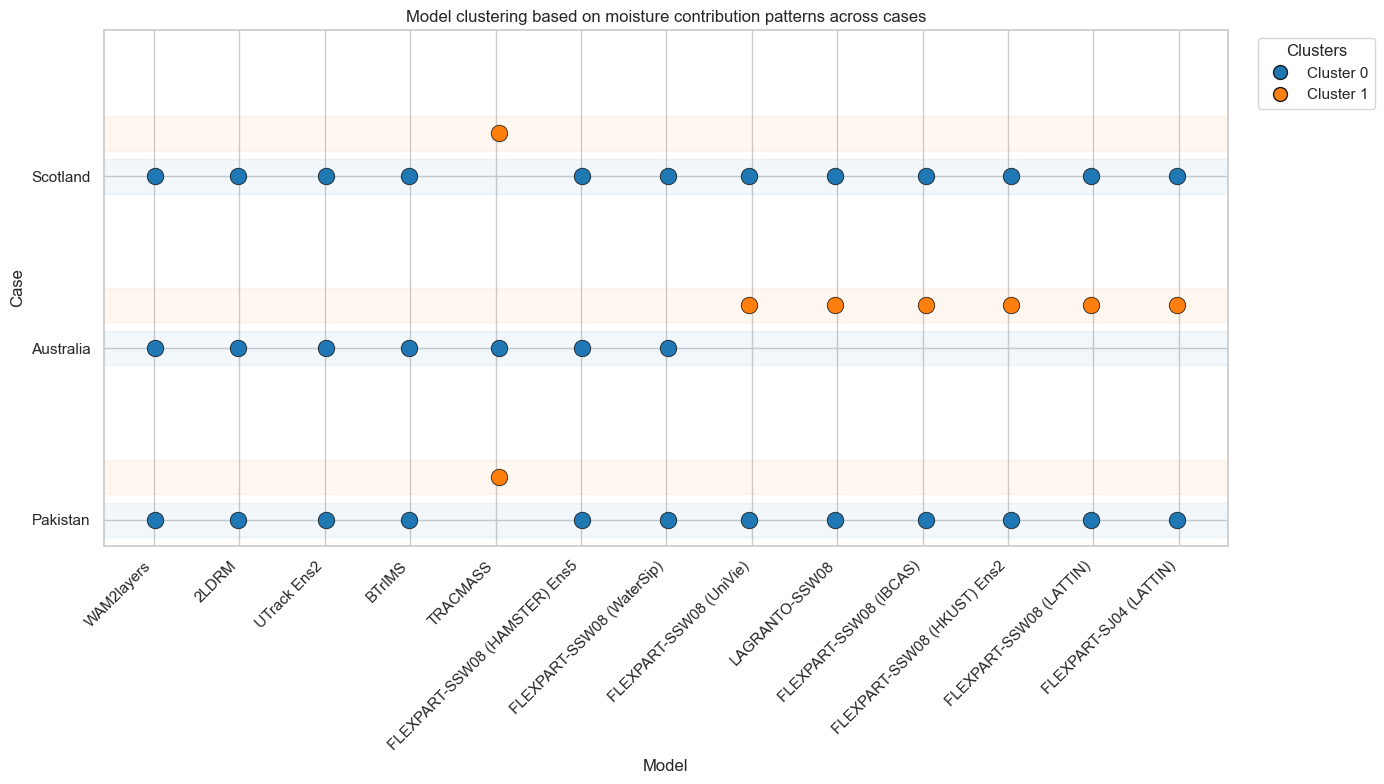

In [75]:
#Make a nicer plot to show which models are in which cluster for all cases
%matplotlib inline
sns.set(style="whitegrid", context="notebook")
plt.figure(figsize=(14, 8))
# Colors for clusters
palette = sns.color_palette("tab10", n_colors=3)    
x = np.arange(len(list_reordered))
# add a small jitter so labels don't overlap
jitter = (np.random.rand(len(x)) - 0.5) * 0.08
for case in cases:          
    kmeans = kmeans_results[case]
    labels = kmeans.labels_
    for i, model in enumerate(list_reordered):
        plt.scatter(i + jitter[i], labels[i] + (cases.index(case) * 4), s=140,
                    color=palette[labels[i]], edgecolor='k', linewidth=0.6)
    # draw horizontal bands for each cluster
    for cluster in np.unique(labels):
        plt.axhspan(cluster - 0.4 + (cases.index(case) * 4),
                    cluster + 0.4 + (cases.index(case) * 4),
                    color=palette[cluster], alpha=0.06)

# Annotate model names below the x-axis and rotate
plt.xticks(x, list_reordered, rotation=45, ha='right')  
# show integer y ticks for cluster indices
plt.yticks(np.arange(0, len(cases) * 4, 4), cases)
plt.ylim(-0.6, len(cases) * 4 - 0.6)
plt.xlabel("Model") 
plt.ylabel("Case")
plt.title("Model clustering based on moisture contribution patterns across cases")
# build a compact legend showing cluster colors
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {c}',
                     markerfacecolor=palette[c], markersize=10, markeredgecolor='k')
           for c in np.unique(labels)]
plt.legend(handles=handles, title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
# save figure to figures path if available
try:
    plt.savefig(figure_path + f'/{n_clusters}cluster_assignment_all_cases.png', dpi=300, bbox_inches='tight')
except Exception:
    pass    

plt.show()


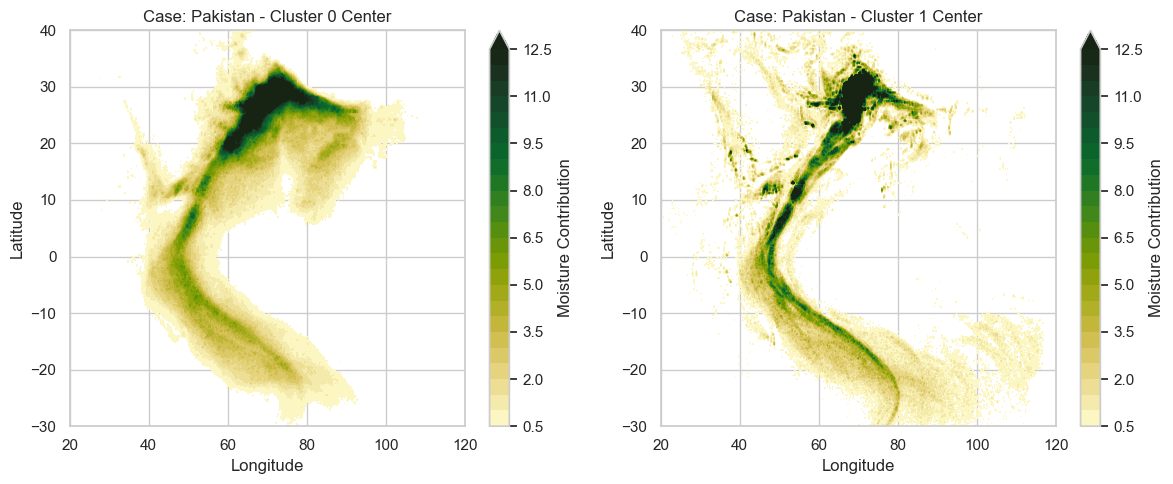

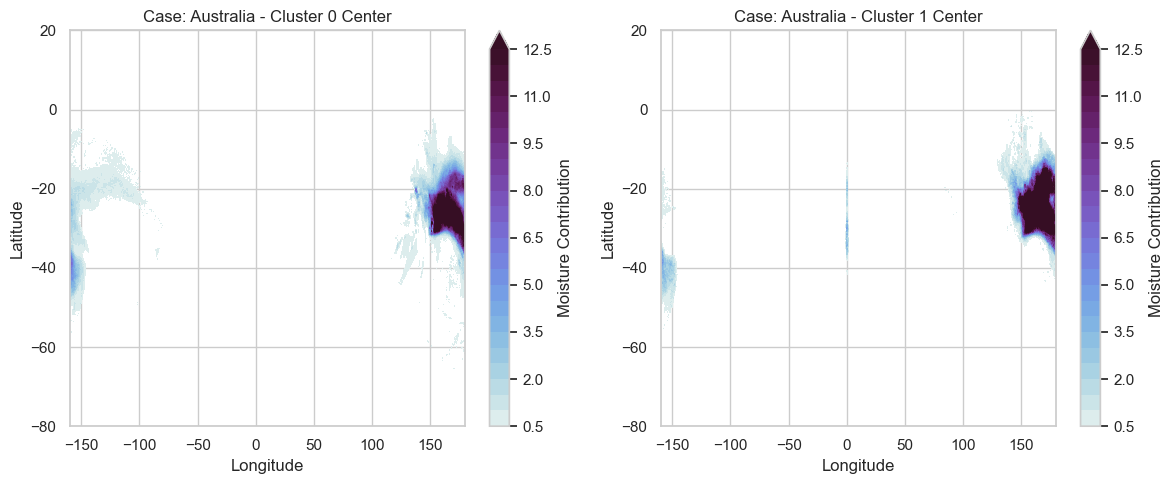

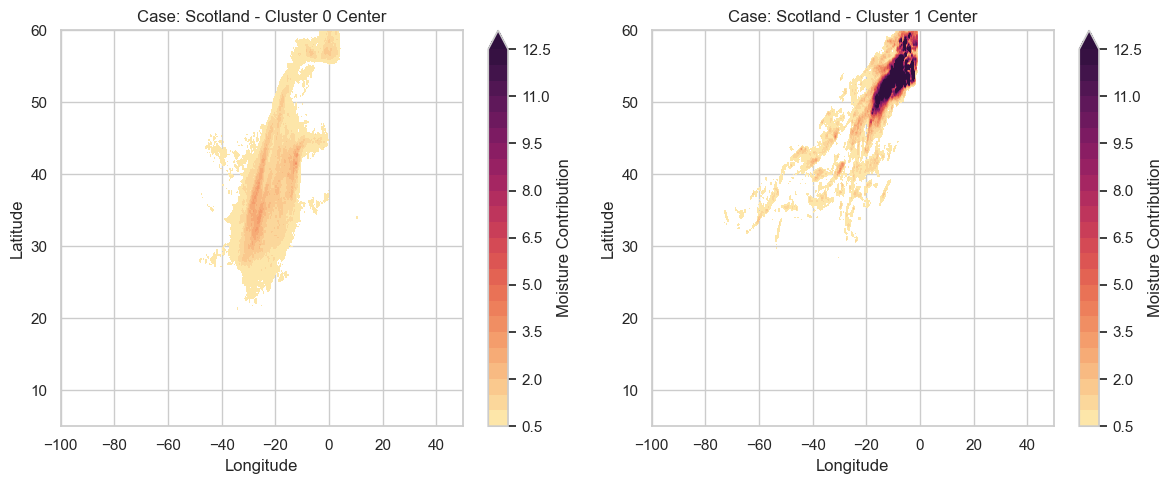

In [76]:
# Make a plot of the cluster centers for each case
import cartopy.crs as ccrs
prjr = ccrs.Robinson(central_longitude=90, globe=None)
prj = ccrs.PlateCarree()

for case in cases:  
    if(case=="Pakistan"):
        cmap = cm.speed
    elif(case=="Australia"):
        cmap = cm.dense
    elif(case=="Scotland"):
        cmap = cm.matter
    
    kmeans = kmeans_results[case]
    cluster_centers = kmeans_results[case+'_centers']
    plt.figure(figsize=(12, 5),transform=prjr)
    #fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": prjr})

    for i in range(n_clusters):
        plt.subplot(1, n_clusters, i + 1)
        plt.contourf(
            kmeans_results[case+'_lon'],
            kmeans_results[case+'_lat'],
            cluster_centers[i, :, :],
            levels=np.linspace(0.5, 12.5, 25),
            extend="max",
            cmap=cmap,
            #transform=prj,
        )
        plt.colorbar(label="Moisture Contribution")
        plt.title(f"Case: {case} - Cluster {i} Center")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
    plt.tight_layout()
    # save figure to figures path if available
    try:
        plt.savefig(figure_path + f'/{n_clusters}cluster_centers_{case}.png', dpi=300, bbox_inches='tight')
    except Exception:
        print("Could not save figure")
        pass
    plt.show()

# Old Plots

In [ ]:
#Make a plot to show which models are in which cluster for specific case
sns.set(style="whitegrid", context="notebook")
plt.figure(figsize=(12, 6))
# Colors for clusters
palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))
x = np.arange(len(all_maps.data_vars))
# add a small jitter so labels don't overlap
jitter = (np.random.rand(len(x)) - 0.5) * 0.08
for i, model in enumerate(all_maps.data_vars):
    plt.scatter(i + jitter[i], labels[i], s=140,
                color=palette[labels[i]], edgecolor='k', linewidth=0.6)
# draw horizontal bands for each cluster
for cluster in np.unique(labels):
    plt.axhspan(cluster - 0.4, cluster + 0.4,
                color=palette[cluster], alpha=0.06)

# Annotate model names below the x-axis and rotate
plt.xticks(x, all_maps.data_vars, rotation=45, ha='right')
# show integer y ticks for cluster indices
plt.yticks(np.unique(labels))
plt.ylim(-0.6, np.max(labels) + 0.6)
plt.xlabel("Model")
plt.ylabel("Cluster")
plt.title("Model clustering based on moisture contribution patterns")
# build a compact legend showing cluster colors
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {c}',
                     markerfacecolor=palette[c], markersize=10, markeredgecolor='k')
           for c in np.unique(labels)]
plt.legend(handles=handles, title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
# save figure to figures path if available
try:
    plt.savefig(figure_path + '/cluster_assignment_' + case + '.png', dpi=150, bbox_inches='tight')
except Exception:
    pass
plt.show()


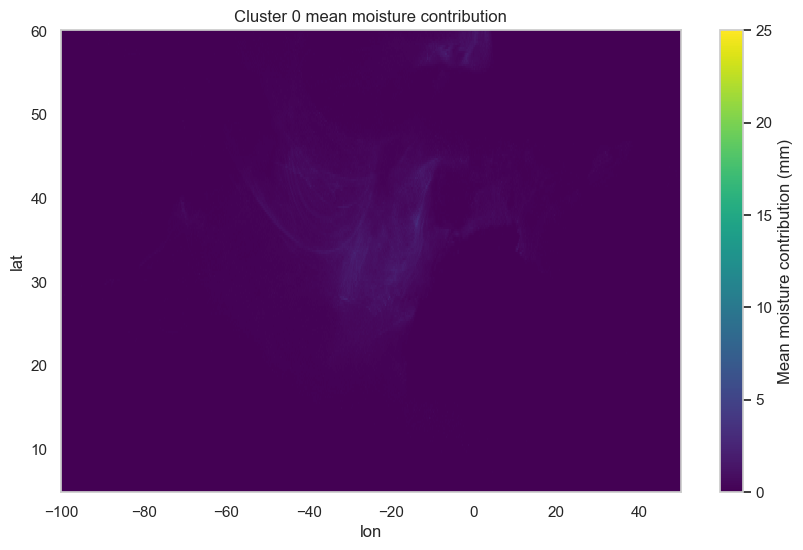

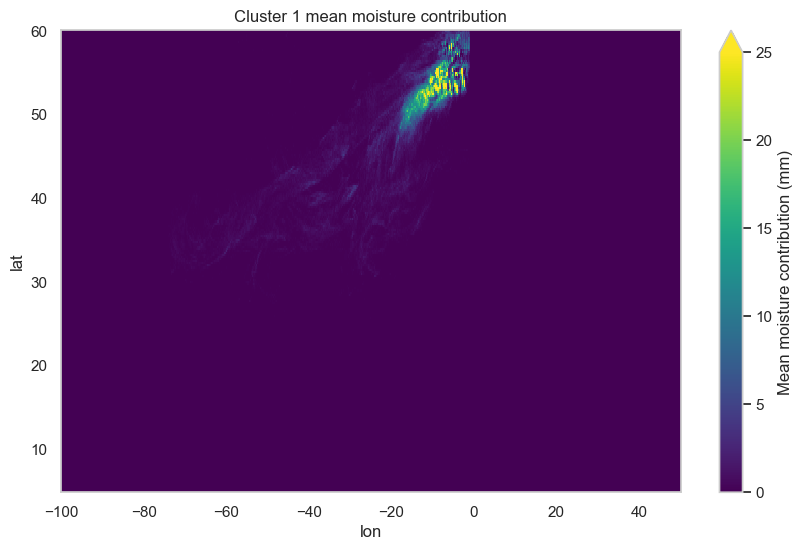

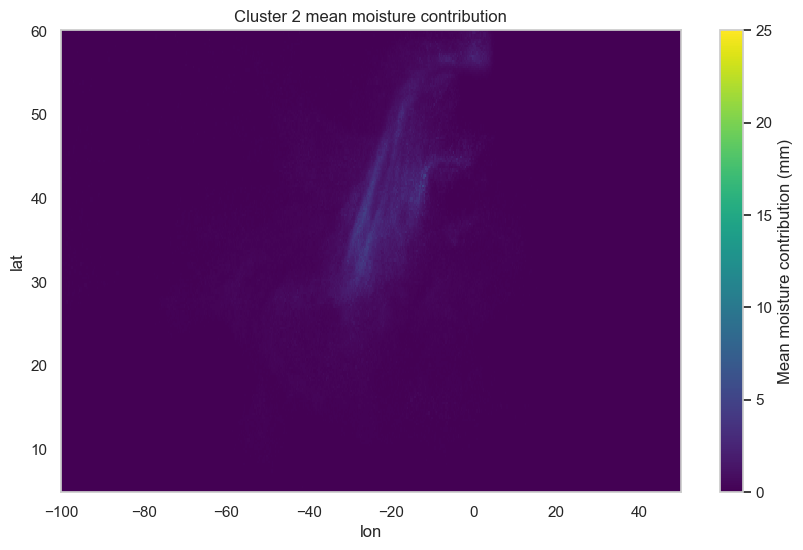

In [ ]:
#Plot mean of different defined clusters
for cluster in np.unique(labels):
    plt.figure(figsize=(10, 6))
    cluster_members = [
        model
        for i, model in enumerate(all_maps.data_vars)
        if labels[i] == cluster
    ]
    cluster_mean = all_maps[cluster_members].to_array(dim='new').mean('new')
    cluster_mean.plot(
        cmap="viridis",
        vmin=0,
        vmax=25,
        cbar_kwargs={"label": "Mean moisture contribution (mm)"},
    )   

    plt.title(f"Cluster {cluster} mean moisture contribution")
    plt.show()

